# User–movie interaction analysis (MovieLens-1M)

Goal: understand how users interact with movies, and decide whether a **generative recommender (GenRec)**
is justified on this data or whether classic statistical / collaborative-filtering methods are enough.

1. Dataset overview
2. How many ratings do users give?
3. How are ratings spread over movies? (popularity / long tail)
4. Rating values
5. Time & sequence structure
6. Item metadata coverage (Wikipedia plots from `phase-1.ipynb`)
7. Baseline experiment: classic methods vs. sequence-aware signal
8. Verdict

In [1]:
from pathlib import Path

from genrec.paths import ML1M_DIR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = ML1M_DIR   # data/ml-1m (genrec.paths)

ratings = pd.read_csv(folder / "ratings.dat", sep="::", engine="python",
                      names=["UserID", "MovieID", "Rating", "Timestamp"])
users = pd.read_csv(folder / "users.dat", sep="::", engine="python",
                    names=["UserID", "Gender", "Age", "Occupation", "ZipCode"])
movies = pd.read_csv(folder / "movies_wiki.csv")   # saved by phase-1.ipynb
ratings["Datetime"] = pd.to_datetime(ratings["Timestamp"], unit="s")

BLUE, ORANGE, INK, GRID = "#2a78d6", "#eb6834", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1. Dataset overview

In [2]:
n_users, n_items, n_ratings = ratings.UserID.nunique(), ratings.MovieID.nunique(), len(ratings)
overview = pd.Series({
    "users": n_users,
    "movies in catalogue": len(movies),
    "movies with >= 1 rating": n_items,
    "ratings": n_ratings,
    "density (ratings / users x rated movies)": f"{n_ratings / (n_users * n_items):.2%}",
    "first rating": ratings.Datetime.min(),
    "last rating": ratings.Datetime.max(),
})
overview.to_frame("value")

,value
users,6040
movies in catalogue,3883
movies with >= 1 rating,3706
ratings,1000209
density (ratings / users x rated movies),4.47%
first rating,2000-04-25 23:05:32
last rating,2003-02-28 17:49:50


For reference, typical e-commerce datasets (Amazon reviews, etc.) have densities around **0.01–0.1%** —
MovieLens-1M is orders of magnitude denser, which is what makes classic collaborative filtering work so well on it.

## 2. How many ratings do users give?

In [3]:
user_counts = ratings.groupby("UserID").size()
user_counts.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_frame("ratings per user")

,ratings per user
count,6040.0
mean,165.6
std,192.7
min,20.0
10%,27.0
25%,44.0
50%,96.0
75%,208.0
90%,400.0
99%,906.7


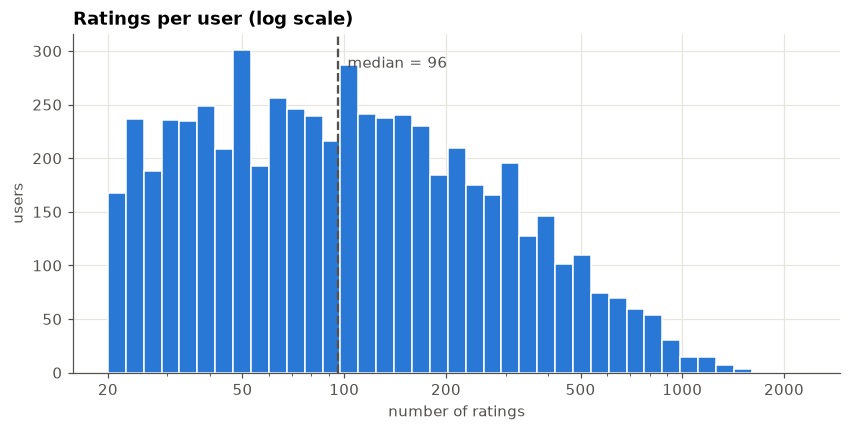

In [4]:
fig, ax = plt.subplots()
bins = np.logspace(np.log10(user_counts.min()), np.log10(user_counts.max()), 40)
ax.hist(user_counts, bins=bins, color=BLUE, edgecolor="white", linewidth=1)
ax.set_xscale("log")
ax.set_xticks([20, 50, 100, 200, 500, 1000, 2000], labels=["20", "50", "100", "200", "500", "1000", "2000"])
ax.axvline(user_counts.median(), color=INK, linestyle="--", linewidth=1.5)
ax.annotate(f"median = {user_counts.median():.0f}", (user_counts.median(), ax.get_ylim()[1] * 0.9),
            xytext=(6, 0), textcoords="offset points", color=INK)
ax.set(title="Ratings per user (log scale)", xlabel="number of ratings", ylabel="users")
plt.show()

In [5]:
user_buckets = pd.cut(user_counts, [19, 49, 99, 199, 499, np.inf],
                      labels=["20–49", "50–99", "100–199", "200–499", "500+"])
pd.DataFrame({
    "users": user_buckets.value_counts().sort_index(),
    "% users": (user_buckets.value_counts(normalize=True).sort_index() * 100).round(1),
    "% ratings": (user_counts.groupby(user_buckets, observed=True).sum() / n_ratings * 100).round(1),
})

,users,% users,% ratings
20–49,1743,28.9,5.7
50–99,1352,22.4,9.6
100–199,1356,22.5,19.0
200–499,1190,19.7,36.7
500+,399,6.6,29.0


In [6]:
# does activity differ by demographic group?
act = users.set_index("UserID").assign(n_ratings=user_counts)
age_labels = {1: "<18", 18: "18–24", 25: "25–34", 35: "35–44", 45: "45–49", 50: "50–55", 56: "56+"}
pd.concat({
    "by gender": act.groupby("Gender").n_ratings.agg(["count", "median", "mean"]),
    "by age": act.groupby(act.Age.map(age_labels), sort=False).n_ratings.agg(["count", "median", "mean"]),
}).round(1)

count  median   mean
by gender F       1709    77.0  144.2
          M       4331   102.0  174.0
by age    <18      222    77.0  122.6
          56+      380    64.0  102.1
          25–34   2096   110.0  188.7
          45–49    550    81.0  152.1
          50–55    496    88.0  146.1
          35–44   1193    94.0  166.8
          18–24   1103   100.0  166.4

Every user has **at least 20 ratings** — GroupLens filtered the dataset that way, so there is **no user cold-start**
in ML-1M. The distribution is still heavy-tailed: a minority of power users contributes a large share of all ratings.

## 3. How are ratings spread over movies?

In [7]:
item_counts = ratings.groupby("MovieID").size().sort_values(ascending=False)
item_counts.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_frame("ratings per movie")

,ratings per movie
count,3706.0
mean,269.9
std,384.0
min,1.0
10%,7.0
25%,33.0
50%,123.5
75%,350.0
90%,729.5
99%,1784.9


In [8]:
item_buckets = pd.cut(item_counts, [0, 4, 19, 99, 499, np.inf], labels=["1–4", "5–19", "20–99", "100–499", "500+"])
pd.DataFrame({
    "movies": item_buckets.value_counts().sort_index(),
    "% movies": (item_buckets.value_counts(normalize=True).sort_index() * 100).round(1),
    "% ratings": (item_counts.groupby(item_buckets, observed=True).sum() / n_ratings * 100).round(1),
})

,movies,% movies,% ratings
1–4,290,7.8,0.1
5–19,373,10.1,0.4
20–99,1024,27.6,5.3
100–499,1401,37.8,34.7
500+,618,16.7,59.5


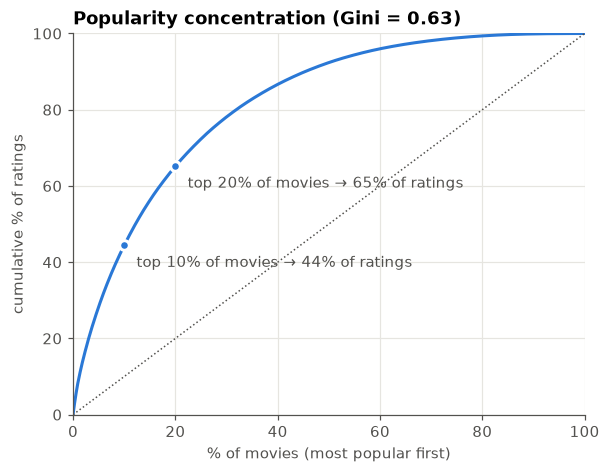

In [9]:
share = item_counts.cumsum().values / n_ratings
x = np.arange(1, n_items + 1) / n_items
gini = 1 - 2 * np.trapezoid(np.sort(item_counts.values).cumsum() / n_ratings, dx=1 / n_items)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(x * 100, share * 100, color=BLUE, linewidth=2)
ax.plot([0, 100], [0, 100], color=INK, linewidth=1, linestyle=":")
for pct in (10, 20):
    y = share[int(n_items * pct / 100) - 1] * 100
    ax.scatter([pct], [y], s=40, color=BLUE, zorder=3, edgecolor="white", linewidth=2)
    ax.annotate(f"top {pct}% of movies → {y:.0f}% of ratings", (pct, y), xytext=(8, -14),
                textcoords="offset points", color=INK)
ax.set(title=f"Popularity concentration (Gini = {gini:.2f})",
       xlabel="% of movies (most popular first)", ylabel="cumulative % of ratings", xlim=(0, 100), ylim=(0, 100))
plt.show()

Classic long tail: a small head of blockbusters receives most of the ratings. That means a plain
**most-popular** recommender is a non-trivial baseline here, and any model has to beat it convincingly.

## 4. Rating values

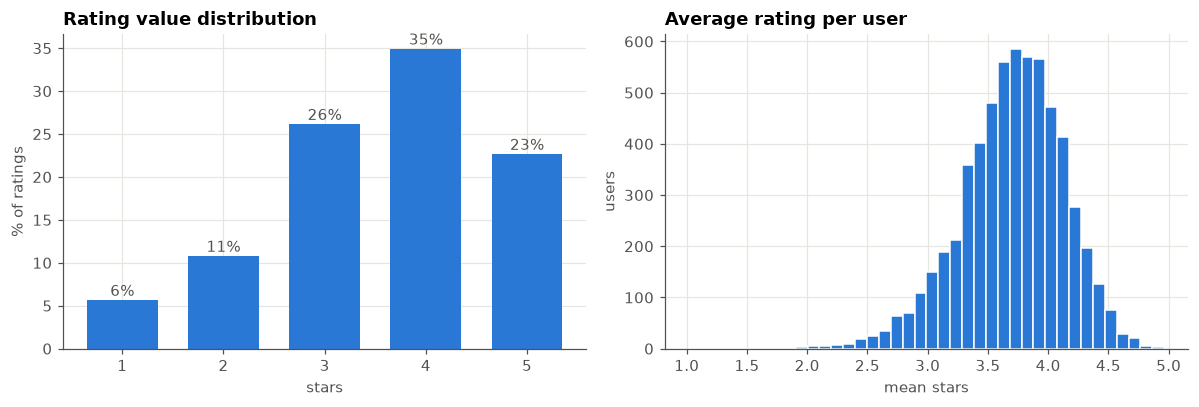

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
dist = ratings.Rating.value_counts(normalize=True).sort_index() * 100
axes[0].bar(dist.index, dist.values, color=BLUE, width=0.7)
for r, v in dist.items():
    axes[0].annotate(f"{v:.0f}%", (r, v), xytext=(0, 3), textcoords="offset points", ha="center", color=INK)
axes[0].set(title="Rating value distribution", xlabel="stars", ylabel="% of ratings")

user_mean = ratings.groupby("UserID").Rating.mean()
axes[1].hist(user_mean, bins=40, color=BLUE, edgecolor="white", linewidth=1)
axes[1].set(title="Average rating per user", xlabel="mean stars", ylabel="users")
plt.tight_layout(); plt.show()

Ratings skew positive (4 is the most common value). Users mostly rate movies they chose to watch, so
*"user rated movie X"* is itself a strong signal — which is why most modern recommenders, including GenRec models
like TIGER / HSTU, treat ML-1M as **implicit feedback** (did the user interact?) rather than predicting stars.

## 5. Time & sequence structure

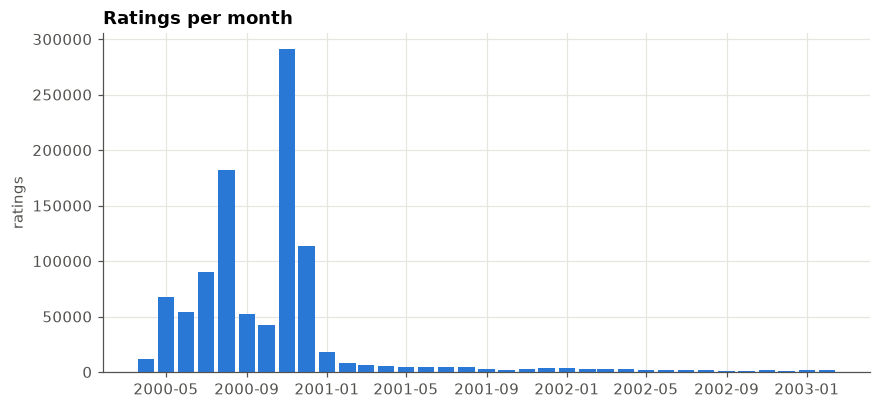

,ratings (top months)
Datetime,
2000-11-01,290793
2000-08-01,182109
2000-12-01,113487
2000-07-01,90334
2000-05-01,67437


In [11]:
monthly = ratings.set_index("Datetime").resample("MS").size()
fig, ax = plt.subplots()
ax.bar(monthly.index, monthly.values, width=25, color=BLUE)
ax.set(title="Ratings per month", ylabel="ratings")
plt.show()
monthly.sort_values(ascending=False).head(5).to_frame("ratings (top months)")

In [12]:
seq = ratings.sort_values(["UserID", "Timestamp"], kind="stable").reset_index(drop=True)
g = seq.groupby("UserID")
first_ts = g.Timestamp.transform("min")
gaps = g.Timestamp.diff().dropna()

per_user = pd.DataFrame({
    "active span (days)": (g.Timestamp.max() - g.Timestamp.min()) / 86400,
    "% ratings in first day": (seq.Timestamp - first_ts < 86400).groupby(seq.UserID).mean() * 100,
})
display(per_user.describe(percentiles=[.25, .5, .75, .9]).round(1))

pd.Series({
    "users whose whole history fits in one day": f"{(per_user['active span (days)'] < 1).mean():.1%}",
    "consecutive ratings with identical timestamp": f"{(gaps == 0).mean():.1%}",
    "consecutive ratings < 1 minute apart": f"{(gaps < 60).mean():.1%}",
    "median gap between consecutive ratings": f"{gaps.median():.0f} s",
}).to_frame("value")

,active span (days),% ratings in first day
count,6040.0,6040.0
mean,95.0,83.5
std,221.9,28.4
min,0.0,0.3
25%,0.0,76.3
50%,0.0,100.0
75%,23.4,100.0
90%,430.2,100.0
max,1033.0,100.0


,value
users whose whole history fits in one day,62.9%
consecutive ratings with identical timestamp,53.2%
consecutive ratings < 1 minute apart,88.5%
median gap between consecutive ratings,0 s


This is the most important property for GenRec / sequential models:

* Most users rate the bulk of their history in **one or a few sessions** right after signing up
  (the MovieLens site asks new users to rate movies to bootstrap recommendations).
* Many consecutive ratings are **seconds apart, or share the exact same timestamp** — the order inside a session
  reflects *the order the website showed movies*, not the order the user watched them.

So the "sequence" in ML-1M is a mix of real taste dynamics and UI artifacts. Sequential models still learn a lot
from it (it is predictable!), but part of what they learn is the website's presentation order. Keep this in mind when
interpreting next-item-prediction results.

## 6. Item metadata coverage

In [13]:
movies["has_plot"] = movies.Plot.notna()
rated = movies.set_index("MovieID").loc[item_counts.index]
cov_by_pop = rated.groupby(item_buckets.reindex(rated.index), observed=True).has_plot.mean() * 100

pd.Series({
    "movies with a Wikipedia plot": f"{movies.has_plot.mean():.1%}",
    "ratings on movies with a plot": f"{rated.has_plot.mul(item_counts).sum() / n_ratings:.1%}",
    "median plot length (words)": int(movies.Plot.dropna().str.split().str.len().median()),
}).to_frame("value")

,value
movies with a Wikipedia plot,72.5%
ratings on movies with a plot,92.7%
median plot length (words),609


In [14]:
cov_by_pop.round(1).to_frame("% movies with plot, by popularity bucket (ratings per movie)")

,"% movies with plot, by popularity bucket (ratings per movie)"
1–4,29.0
5–19,43.4
20–99,69.0
100–499,88.9
500+,95.3


Coverage is much better when weighted by interactions: popular movies almost always have a plot; the gaps
are mainly in the long tail. For a GenRec model that builds **semantic IDs** from item text (TIGER-style),
the remaining movies can fall back to *title + year + genres*, which every movie has.

## 7. Baseline experiment

Standard sequential-recommendation protocol (as used by SASRec, BERT4Rec, TIGER, HSTU on ML-1M):

* sort each user's ratings by time, hold out the **last** item as test and the second-to-last as validation;
* treat ratings as implicit interactions; rank **all** movies the user has not rated (full ranking, no negative sampling);
* report **HR@10** (is the true next movie in the top 10?) and **NDCG@10** (how high is it?).

Models — all closed-form "statistical" methods, no deep learning:

| model | uses | idea |
|---|---|---|
| Random | – | floor |
| MostPop | item counts | recommend blockbusters |
| ItemKNN | whole history (unordered) | cosine item–item co-occurrence |
| EASE | whole history (unordered) | linear item–item autoencoder, a very strong CF baseline |
| Markov-1 | **last item only** | "people who rated X next rated Y" transition counts |

If an order-aware model that sees *only one item* competes with CF models that see the *whole* history,
the data carries strong sequential signal — exactly what a generative / sequential recommender is designed to exploit.

In [15]:
item_ids = np.sort(ratings.MovieID.unique())
seq["u"] = pd.factorize(seq.UserID)[0]
seq["i"] = np.searchsorted(item_ids, seq.MovieID)
pos_from_end = seq.groupby("u").cumcount(ascending=False)

train      = seq[pos_from_end >= 2]   # used to tune on validation
train_full = seq[pos_from_end >= 1]   # train + validation, used for the final test
val_target  = seq[pos_from_end == 1].set_index("u").i.sort_index().values
test_target = seq[pos_from_end == 0].set_index("u").i.sort_index().values
rng = np.random.default_rng(0)

def interaction_matrix(df):
    X = np.zeros((n_users, n_items), dtype=np.float32)
    X[df.u.values, df.i.values] = 1
    return X

def evaluate(scores, X_hist, target, k=10):
    """Full-ranking HR@k / NDCG@k; already-rated movies are excluded, ties broken at random."""
    s = np.where(X_hist > 0, -np.inf, scores)
    t = s[np.arange(n_users), target][:, None]
    rank = (s > t).sum(1) + rng.integers(0, (s == t).sum(1))   # 0-based
    hit = rank < k
    return {f"HR@{k}": hit.mean(), f"NDCG@{k}": (hit / np.log2(rank + 2)).mean()}

In [16]:
def random_scores(X):
    return rng.random(X.shape, dtype=np.float32)

def pop_scores(X):
    return np.broadcast_to(X.sum(0), X.shape)

def itemknn_scores(X, X_query=None):
    norms = np.sqrt(X.sum(0)) + 1e-9
    S = (X.T @ X) / norms[:, None] / norms[None, :]
    np.fill_diagonal(S, 0)
    return (X if X_query is None else X_query) @ S

def ease_scores(X, lam):
    G = (X.T @ X).astype(np.float64)
    G[np.diag_indices_from(G)] += lam
    P = np.linalg.inv(G)
    B = -P / np.diag(P)
    np.fill_diagonal(B, 0)
    return X @ B.astype(np.float32)

def markov_scores(df, X, query):
    """Score = how often each movie was rated right after the query movie; popularity breaks ties."""
    T = np.zeros((n_items, n_items), dtype=np.float32)
    prev = df.groupby("u").i.shift()
    m = prev.notna()
    np.add.at(T, (prev[m].astype(int).values, df.i[m].values), 1)
    pop = X.sum(0)
    return T[query] + 1e-3 * pop / pop.max()

def last_items(df, n=1):
    return df.groupby("u").tail(n)

X_train, X_full = interaction_matrix(train), interaction_matrix(train_full)

In [17]:
# tune EASE's regularisation on the validation item
lam_results = {lam: evaluate(ease_scores(X_train, lam), X_train, val_target)["NDCG@10"]
               for lam in [100, 300, 1000, 3000]}
best_lam = max(lam_results, key=lam_results.get)
print("validation NDCG@10 by lambda:", {k: round(v, 4) for k, v in lam_results.items()}, "-> best", best_lam)

validation NDCG@10 by lambda: {100: np.float64(0.0514), 300: np.float64(0.0523), 1000: np.float64(0.0508), 3000: np.float64(0.0478)} -> best 300


In [18]:
last_full = last_items(train_full).set_index("u").i.sort_index().values
rand_full = train_full.groupby("u").sample(1, random_state=0).set_index("u").i.sort_index().values
X_recent = interaction_matrix(last_items(train_full, 10))

results = pd.DataFrame({
    "Random":                     evaluate(random_scores(X_full), X_full, test_target),
    "MostPop":                    evaluate(pop_scores(X_full), X_full, test_target),
    "ItemKNN (all history)":      evaluate(itemknn_scores(X_full), X_full, test_target),
    "ItemKNN (last 10 items)":    evaluate(itemknn_scores(X_full, X_recent), X_full, test_target),
    f"EASE (λ={best_lam})":       evaluate(ease_scores(X_full, best_lam), X_full, test_target),
    "Markov-1 (random past item)": evaluate(markov_scores(train_full, X_full, rand_full), X_full, test_target),
    "Markov-1 (last item)":       evaluate(markov_scores(train_full, X_full, last_full), X_full, test_target),
}).T.sort_values("NDCG@10")
results.round(4)

,HR@10,NDCG@10
Random,0.0025,0.0011
MostPop,0.0363,0.0178
Markov-1 (random past item),0.0373,0.0196
ItemKNN (all history),0.0704,0.0365
EASE (λ=300),0.1084,0.0536
ItemKNN (last 10 items),0.1414,0.0759
Markov-1 (last item),0.2151,0.1261


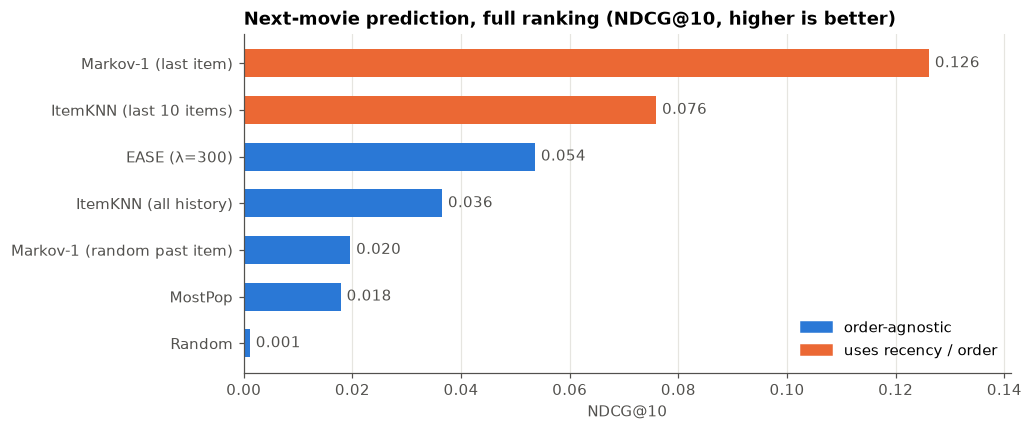

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
order_aware = results.index.str.contains("last")
ax.barh(results.index, results["NDCG@10"], color=np.where(order_aware, ORANGE, BLUE), height=0.6)
for y, v in enumerate(results["NDCG@10"]):
    ax.annotate(f"{v:.3f}", (v, y), xytext=(4, 0), textcoords="offset points", va="center", color=INK)
ax.set(title="Next-movie prediction, full ranking (NDCG@10, higher is better)", xlabel="NDCG@10")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, results["NDCG@10"].max() * 1.12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="order-agnostic"), Patch(color=ORANGE, label="uses recency / order")],
          loc="lower right", frameon=False)
plt.show()

### Reference points from the literature (same protocol: ML-1M, leave-last-out, full ranking)

Published numbers vary with preprocessing, so treat these as ballpark only:

| model | type | HR@10 | NDCG@10 |
|---|---|---|---|
| SASRec | sequential transformer | ~0.22–0.29 | ~0.12–0.16 |
| HSTU (Meta, 2024) | generative sequential | ~0.33 | ~0.19 |

Compare these with the closed-form baselines above.

### Robustness check: is the sequential signal just timestamp-tie order?

53% of consecutive ratings share the same timestamp, so the order *inside* a second is arbitrary (file order).
Shuffle the ties randomly and re-run the two key models.

In [20]:
seq_shuf = (ratings.sample(frac=1, random_state=1)
            .sort_values(["UserID", "Timestamp"], kind="stable").reset_index(drop=True))
seq_shuf["u"] = pd.factorize(seq_shuf.UserID)[0]
seq_shuf["i"] = np.searchsorted(item_ids, seq_shuf.MovieID)
pfe = seq_shuf.groupby("u").cumcount(ascending=False)
shuf_train, shuf_target = seq_shuf[pfe >= 1], seq_shuf[pfe == 0].set_index("u").i.sort_index().values
X_shuf = interaction_matrix(shuf_train)
shuf_last = last_items(shuf_train).set_index("u").i.sort_index().values

pd.DataFrame({
    f"EASE (λ={best_lam})":   evaluate(ease_scores(X_shuf, best_lam), X_shuf, shuf_target),
    "Markov-1 (last item)": evaluate(markov_scores(shuf_train, X_shuf, shuf_last), X_shuf, shuf_target),
}).T.round(4)

,HR@10,NDCG@10
EASE (λ=300),0.1078,0.0534
Markov-1 (last item),0.1859,0.1090


Markov-1 drops somewhat (part of its edge came from tie order) but still roughly **doubles** EASE.
The sequential signal is real, not just an artifact of how ties are stored.

## 8. Verdict — GenRec or classic statistics?

**What the data looks like**

* Small, dense catalogue: 3.7k movies, 6k users, 1M ratings, **4.5% density** (e-commerce data is ~100× sparser).
* Every user has ≥ 20 ratings (median **96**) → long histories, **no user cold-start**.
* Strong popularity skew: the top 20% of movies get ~2/3 of all ratings; MostPop is a real baseline.
* Most users rate their whole history in **one sitting** (63% within a single day; median gap between ratings 0 s).
* 93% of all ratings are on movies that have a Wikipedia plot → good text coverage for content-based / semantic IDs.

**What the experiment says**

* Order-agnostic statistical CF is solid: EASE ≈ 0.054 NDCG@10, 3× MostPop.
* But a model that looks at **only the last movie** (Markov-1) gets ≈ **0.126 NDCG@10 — 2.3× EASE**, and still ~2×
  after shuffling timestamp ties. ItemKNN restricted to the last 10 items also beats ItemKNN on the full history,
  while Markov from a *random* past item is no better than MostPop. → **Recency and order carry most of the signal.**
* Published sequential / generative models on this protocol reach ~0.12–0.16 (SASRec) and ~0.19 (HSTU) NDCG@10 —
  well above EASE, but the gap over a trivial Markov chain is much smaller than the gap over EASE.

**Recommendation**

1. **For next-item prediction (the standard GenRec task), a sequential/generative model is justified** — the data has
   a strong, learnable sequential structure that classic order-agnostic methods (EASE, ItemKNN, MF) cannot use.
2. **But the bar is not MostPop — it is Markov-1 (~0.126 NDCG@10) and SASRec.** A GenRec model that doesn't clearly
   beat Markov-1 isn't adding value. Keep Pop / EASE / Markov-1 in every results table.
3. **Be honest about what "sequence" means here.** Much of ML-1M's order is the MovieLens sign-up rating flow, not real
   viewing order. Gains on ML-1M may not transfer to production data; validate on a second dataset if possible.
4. **If the goal is "which movies will this user like" (an unordered top-N list), classic methods are enough** —
   EASE is a single matrix inverse, trains in seconds, and is hard to beat for that objective.
5. GenRec-specific notes for this dataset: the catalogue is small, so the scalability benefit of semantic IDs (TIGER)
   isn't needed — their value here would be sharing content (plots / genres) with tail movies. 1M interactions is
   small for a big transformer, so start with small models and strong regularisation.

**Next step:** train SASRec (the standard sequential baseline) with the same split and metrics, then the GenRec model,
and compare all of them against the table in section 7.